# PanopTILs cell-type deconvolution — Figures 4C and S5B

Reproduces the PanopTILs (TCGA archival diagnostic-slide) cell-type results
from Shulman et al., *Cell* 2026.

Two predictors of cancer / lymphocyte / stromal abundance per ROI:

- **Supervised H&E-ST model** — a 5-fold MLP regressor trained on PanopTILs
  pathologist-annotated fractions, taking Path2Space-inferred expression as
  input. Each fold's model predicts on its held-out ROIs (5-fold CV).
- **SpaCET on H&E-inferred ST** — the unsupervised SpaCET deconvolution applied
  to Path2Space-inferred expression.

Both are scored against pathologist fractions per slide: Pearson correlation
(PCC) and AUC (ROI contains vs lacks a cell type, label > 0), averaged over the
20 slides with ≥ 20 ROIs. **Figure 4C** = SpaCET AUC; **Figure S5B** = SpaCET
vs supervised model, PCC and AUC.

Models: `models/deconv_fold_{0-4}.joblib` — the `MinMaxScaler → MLPRegressor`
pipelines behind the published figure (`mlp_results_1000_MinMaxScaler_all_frac_main`).

## Setup

In [1]:
import joblib
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

CELL_TYPES = ["TILs", "Stromal", "Epithelial"]   # MLP output order
CT_LABEL   = {"Epithelial": "Cancer", "TILs": "Lympho.", "Stromal": "Stromal"}
ORDER      = ["Cancer", "Lympho.", "Stromal"]

## Load data

`tcga_panoptils_expression.csv.gz` holds the Path2Space-inferred expression
restricted to the 1,448 genes the five fold-models use; `tcga_panoptils_labels.csv`
holds the pathologist fractions, the slide id, and the CV fold of each ROI.

In [2]:
expr   = pd.read_csv("../data/tcga_panoptils_expression.csv.gz", index_col=0)
labels = pd.read_csv("../data/tcga_panoptils_labels.csv", index_col=0)
print(f"{expr.shape[0]} PanopTILs ROIs x {expr.shape[1]} genes")
print("ROIs per CV fold:", labels["fold"].value_counts().sort_index().to_dict())

1317 PanopTILs ROIs x 1448 genes
ROIs per CV fold: {0: 171, 1: 208, 2: 208, 3: 353, 4: 377}


## Supervised model — 5-fold cross-validated prediction

Each fold's model is loaded and applied to that fold's held-out ROIs; the five
test-fold prediction sets are pooled into one CV prediction per ROI.

In [3]:
model_pred = []
for i in range(5):
    model = joblib.load(f"../models/deconv_fold_{i}.joblib")
    feats = model.named_steps["scaler"].get_feature_names_out()
    test_roi = labels.index[labels["fold"] == i]
    p = model.predict(expr.loc[test_roi, feats])
    model_pred.append(pd.DataFrame(p, index=test_roi, columns=CELL_TYPES))
model_pred = pd.concat(model_pred).loc[expr.index]
print("pooled 5-fold CV predictions:", model_pred.shape)

pooled 5-fold CV predictions: (1317, 3)


## SpaCET on H&E-inferred ST

SpaCET returns 35 fine-grained cell types; these are collapsed to the three
coarse classes, summed, and row-softmax-normalised (the `Unidentifiable` class
is dropped), exactly as in the paper's plotting pipeline.

In [4]:
CELL_TYPE_MAP = {
    "Malignant": "Epithelial", "CAF": "Stromal", "Endothelial": "Stromal",
    "Plasma": "TILs", "B cell": "TILs", "T CD4": "TILs", "T CD8": "TILs",
    "NK": "Unidentifiable", "cDC": "Stromal", "pDC": "Stromal",
    "Macrophage": "Stromal", "Mast": "TILs", "Neutrophil": "TILs",
    "B cell naive": "TILs", "B cell non-switched memory": "TILs",
    "B cell switched memory": "TILs", "B cell exhausted": "TILs",
    "T CD4 naive": "TILs", "Th1": "TILs", "Th2": "TILs", "Th17": "TILs",
    "Tfh": "TILs", "Treg": "TILs", "T CD8 naive": "TILs",
    "T CD8 central memory": "TILs", "T CD8 effector memory": "TILs",
    "T CD8 effector": "TILs", "T CD8 exhausted": "TILs",
    "cDC1 CLEC9A": "Stromal", "cDC2 CD1C": "Stromal", "cDC3 LAMP3": "Stromal",
    "Macrophage M1": "Stromal", "Macrophage M2": "Stromal",
    "Macrophage other": "Stromal", "Unidentifiable": "Unidentifiable",
}

def softmax_rows(df):
    e = np.exp(df.values)
    return pd.DataFrame(e / e.sum(1, keepdims=True), index=df.index, columns=df.columns)

spacet_raw = pd.read_csv("../data/panoptils_spacet_inferred.csv", index_col=0)
sp = spacet_raw.loc[spacet_raw.index.isin(CELL_TYPE_MAP)].copy()
sp.index = sp.index.map(CELL_TYPE_MAP)
sp = sp.groupby(level=0).sum().T.loc[expr.index].drop(columns="Unidentifiable")
spacet_pred = softmax_rows(sp)[CELL_TYPES]
print("SpaCET-inferred predictions:", spacet_pred.shape)

SpaCET-inferred predictions: (1317, 3)


## Per-slide PCC and AUC

For every slide with ≥ 20 ROIs, PCC and AUC are computed per cell type, then
averaged across slides. AUC binarises the pathologist fraction at > 0
(ROI contains vs lacks the cell type).

In [5]:
sc = labels["slide"].value_counts()
valid_slides = sc[sc >= 20].index
print(f"{len(valid_slides)} slides with >= 20 ROIs")

def per_slide_long(pred, method):
    """Per-(slide, cell type) PCC and AUC for one predictor."""
    rows = []
    for ct in CELL_TYPES:
        for s in valid_slides:
            idx = labels.index[labels["slide"] == s]
            y, p = labels.loc[idx, ct].values, pred.loc[idx, ct].values
            ybin = (y > 0).astype(int)
            pcc = pearsonr(y, p)[0] if np.std(y) > 0 and np.std(p) > 0 else np.nan
            auc = roc_auc_score(ybin, p) if len(np.unique(ybin)) > 1 else np.nan
            rows.append({"cell_type": CT_LABEL[ct], "method": method,
                         "slide": s, "PCC": pcc, "AUC": auc})
    return pd.DataFrame(rows)

per_slide = pd.concat([
    per_slide_long(spacet_pred, "SpaCET-H&E-inferred ST"),
    per_slide_long(model_pred,  "H&E-ST model"),
], ignore_index=True)

summary = (per_slide.groupby(["method", "cell_type"])[["PCC", "AUC"]]
           .mean().round(3).reindex(ORDER, level=1))
summary

20 slides with >= 20 ROIs


PCC    AUC
method                 cell_type              
H&E-ST model           Cancer     0.793  0.876
                       Lympho.    0.789  0.858
                       Stromal    0.592  0.836
SpaCET-H&E-inferred ST Cancer     0.693  0.849
                       Lympho.    0.570  0.791
                       Stromal    0.404  0.850

## Figure S5B — SpaCET vs supervised model

Bars are the mean over slides; error bars are the 95% CI across slides.

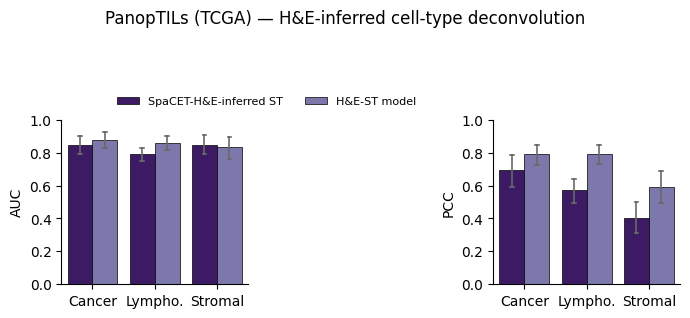

In [6]:
bar_colors = ["#3b0f70", "#7570b3"]   # SpaCET (dark), H&E-ST model
hue_order  = ["SpaCET-H&E-inferred ST", "H&E-ST model"]

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))
for ax, metric in zip(axes, ["AUC", "PCC"]):
    sns.barplot(data=per_slide, x="cell_type", y=metric, hue="method",
                order=ORDER, hue_order=hue_order, palette=bar_colors,
                capsize=0.12, err_kws={"linewidth": 1.2, "color": "dimgray"},
                edgecolor="black", linewidth=0.5, ax=ax)
    ax.set(ylim=(0, 1.0), xlabel="", ylabel=metric)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.legend_.remove()
axes[0].legend(loc="lower center", bbox_to_anchor=(1.1, 1.02), ncol=2,
               frameon=False, fontsize=8)
sns.despine()
fig.suptitle("PanopTILs (TCGA) — H&E-inferred cell-type deconvolution", y=1.12)
fig.tight_layout()
plt.show()

## Figure 4C — PanopTILs SpaCET AUC

The SpaCET-on-inferred AUC per cell type, with one point per slide.

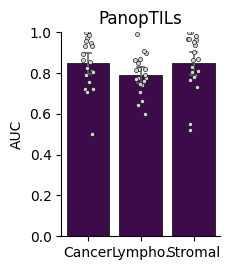

In [7]:
sp_auc = per_slide[per_slide["method"] == "SpaCET-H&E-inferred ST"]

fig, ax = plt.subplots(figsize=(2.4, 2.8))
sns.barplot(data=sp_auc, x="cell_type", y="AUC", order=ORDER,
            color="#440154", edgecolor="black", linewidth=0.5,
            capsize=0.12, err_kws={"linewidth": 1.2, "color": "dimgray"}, ax=ax)
sns.stripplot(data=sp_auc, x="cell_type", y="AUC", order=ORDER,
              color="lightgray", size=3, edgecolor="black", linewidth=0.4, ax=ax)
ax.set(ylim=(0, 1.0), xlabel="", ylabel="AUC", title="PanopTILs")
ax.set_yticks(np.arange(0, 1.01, 0.2))
sns.despine()
fig.tight_layout()
plt.show()

## Summary vs the paper

Paper Figure S5B / 4C (Cancer / Lympho. / Stromal):

| | SpaCET PCC | SpaCET AUC | Model PCC | Model AUC |
|---|---|---|---|---|
| Paper | 0.69 / 0.60 / 0.41 | 0.85 / 0.80 / 0.85 | 0.80 / 0.80 / 0.60 | 0.88 / 0.87 / 0.85 |

In [8]:
for method in hue_order:
    s = summary.loc[method]
    print(method)
    for ct in ORDER:
        print(f"  {ct:<8} PCC={s.loc[ct,'PCC']:.3f}  AUC={s.loc[ct,'AUC']:.3f}")

SpaCET-H&E-inferred ST
  Cancer   PCC=0.693  AUC=0.849
  Lympho.  PCC=0.570  AUC=0.791
  Stromal  PCC=0.404  AUC=0.850
H&E-ST model
  Cancer   PCC=0.793  AUC=0.876
  Lympho.  PCC=0.789  AUC=0.858
  Stromal  PCC=0.592  AUC=0.836
